In [ ]:

from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Optional, Tuple, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# ============================================================
# Config
# ============================================================

@dataclass
class DDPMConfig:
    input_dim: int
    context_length: int = 24
    prediction_length: int = 1

    rnn_type: str = "GRU"   # "GRU" or "LSTM"
    rnn_hidden_dim: int = 64
    rnn_layers: int = 2
    rnn_dropout: float = 0.1

    unet_base_channels: int = 32
    unet_depth: int = 3
    time_embed_dim: int = 128

    diffusion_steps: int = 1000
    beta_start: float = 1e-4
    beta_end: float = 2e-2

    lr: float = 1e-3
    batch_size: int = 128
    epochs: int = 100
    grad_clip: float = 1.0
    weight_decay: float = 0.0

    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    scale_condition: float = 1.0


# ============================================================
# Dataset
# ============================================================

class RollingWindowDataset(Dataset):
    """
    Build (context, target) pairs from a multivariate time series.

    Input series shape:
        [T, D]

    Each sample:
        context: [context_length, D]
        target:  [prediction_length, D]
    """
    def __init__(
        self,
        series: np.ndarray | torch.Tensor,
        context_length: int,
        prediction_length: int,
        stride: int = 1,
        normalize: bool = False,
        eps: float = 1e-6,
    ) -> None:
        super().__init__()

        x = torch.as_tensor(series, dtype=torch.float32)
        if x.ndim != 2:
            raise ValueError(f"series must have shape [T, D], got {tuple(x.shape)}")

        self.context_length = context_length
        self.prediction_length = prediction_length
        self.stride = stride
        self.normalize = normalize
        self.eps = eps

        self.mean = x.mean(dim=0, keepdim=True)
        self.std = x.std(dim=0, keepdim=True).clamp_min(eps)

        if normalize:
            x = (x - self.mean) / self.std

        self.series = x
        self.indices = []
        max_start = len(x) - context_length - prediction_length + 1
        for start in range(0, max_start, stride):
            self.indices.append(start)

        if not self.indices:
            raise ValueError("Not enough data to create even one sample.")

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
      start = self.indices[idx]
      Lc = self.context_length
      Lp = self.prediction_length

      # context: [Lc, D]
      context = self.series[start : start + Lc]

      # repo-style target:
      # target[j] is the future return after context step j
      targets = []
      for j in range(Lc):
          y0 = start + j + 1
          y1 = y0 + Lp
          targets.append(self.series[y0:y1])  # [Lp, D]

      # target: [Lc, Lp, D]
      target = torch.stack(targets, dim=0)

      return {
          "context": context,
          "target": target,
      }

# ============================================================
# UNet blocks
# ============================================================

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim: int) -> None:
        super().__init__()
        self.dim = dim

    def forward(self, timesteps: torch.Tensor) -> torch.Tensor:
        device = timesteps.device
        half_dim = self.dim // 2
        if half_dim == 0:
            return timesteps.float().unsqueeze(-1)

        exponent = torch.exp(
            torch.arange(half_dim, device=device, dtype=torch.float32)
            * -(math.log(10000.0) / max(half_dim - 1, 1))
        )
        emb = timesteps.float().unsqueeze(1) * exponent.unsqueeze(0)
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class FiLM(nn.Module):
    def __init__(self, channels: int, cond_dim: int) -> None:
        super().__init__()
        self.to_scale_shift = nn.Sequential(
            nn.SiLU(),
            nn.Linear(cond_dim, channels * 2),
        )

    def forward(self, x: torch.Tensor, cond_vec: torch.Tensor) -> torch.Tensor:
        gamma, beta = self.to_scale_shift(cond_vec).chunk(2, dim=-1)
        return (1.0 + gamma.unsqueeze(-1)) * x + beta.unsqueeze(-1)


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, cond_dim: int) -> None:
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(1, out_channels)
        self.film1 = FiLM(out_channels, cond_dim)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(1, out_channels)
        self.film2 = FiLM(out_channels, cond_dim)

    def forward(self, x: torch.Tensor, cond_vec: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.norm1(x)
        x = self.film1(x, cond_vec)
        x = F.silu(x)

        x = self.conv2(x)
        x = self.norm2(x)
        x = self.film2(x, cond_vec)
        x = F.silu(x)
        return x


class Down(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, cond_dim: int) -> None:
        super().__init__()
        self.block = ConvBlock(in_channels, out_channels, cond_dim)

    def forward(self, x: torch.Tensor, cond_vec: torch.Tensor) -> torch.Tensor:
        return self.block(x, cond_vec)


class Up(nn.Module):
    def __init__(
        self,
        in_channels: int,
        skip_channels: int,
        out_channels: int,
        cond_dim: int,
    ) -> None:
        super().__init__()
        self.block = ConvBlock(in_channels + skip_channels, out_channels, cond_dim)

    def forward(
        self,
        x: torch.Tensor,
        skip: torch.Tensor,
        cond_vec: torch.Tensor,
    ) -> torch.Tensor:
        x = torch.cat([skip, x], dim=1)
        return self.block(x, cond_vec)


class UNet1DSameRes(nn.Module):
    """
    Same-resolution 1D U-Net.

    Keeps the repo's basic idea:
      - x shape is [B, prediction_length, target_dim]
      - cond shape is [B, 1, hidden_dim]
      - if hidden_dim != target_dim, project condition length to target_dim
    """
    def __init__(
        self,
        in_channels: int,
        cond_channels: int,
        time_embed_dim: int = 128,
        base_channels: int = 32,
        depth: int = 3,
    ) -> None:
        super().__init__()
        self.cond_channels = cond_channels
        self.len_proj = nn.ModuleDict()

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_embed_dim),
            nn.Linear(time_embed_dim, time_embed_dim * 2),
            nn.SiLU(),
            nn.Linear(time_embed_dim * 2, time_embed_dim),
        )

        total_in = in_channels + cond_channels
        self.inc = ConvBlock(total_in, base_channels, time_embed_dim)

        ch = base_channels
        enc_channels = [ch]
        self.downs = nn.ModuleList()
        for _ in range(depth):
            self.downs.append(Down(ch, ch * 2, time_embed_dim))
            ch *= 2
            enc_channels.append(ch)

        self.bottleneck = ConvBlock(ch, ch, time_embed_dim)

        self.ups = nn.ModuleList()
        for skip_ch in reversed(enc_channels[:-1]):
            self.ups.append(Up(ch, skip_ch, skip_ch, time_embed_dim))
            ch = skip_ch

        self.out = nn.Conv1d(base_channels, in_channels, kernel_size=1)

    def _project_cond_length(self, cond: torch.Tensor, target_len: int) -> torch.Tensor:
        b, c, cond_len = cond.shape
        key = f"{cond_len}->{target_len}"
        if key not in self.len_proj:
            self.len_proj[key] = nn.Linear(cond_len, target_len, bias=False).to(cond.device)
        proj = self.len_proj[key]
        cond = proj(cond.reshape(b * c, cond_len)).reshape(b, c, target_len)
        return cond

    def forward(
        self,
        x: torch.Tensor,              # [B, pred_len, target_dim]
        t: torch.Tensor,              # [B]
        cond: Optional[torch.Tensor], # [B, 1, hidden_dim]
    ) -> torch.Tensor:
        if self.cond_channels > 0:
            if cond is None:
                raise ValueError("cond is required")
            if cond.shape[1] != self.cond_channels:
                raise ValueError(
                    f"Expected cond_channels={self.cond_channels}, got {cond.shape[1]}"
                )
            if cond.shape[-1] != x.shape[-1]:
                cond = self._project_cond_length(cond, x.shape[-1])
            x = x + cond
            x = torch.cat([x, cond], dim=1)

        cond_vec = self.time_mlp(t)

        skips = []
        x = self.inc(x, cond_vec)
        skips.append(x)

        for down in self.downs:
            x = down(x, cond_vec)
            skips.append(x)

        x = self.bottleneck(x, cond_vec)

        for up, skip in zip(self.ups, reversed(skips[:-1])):
            x = up(x, skip, cond_vec)

        return self.out(x)


# ============================================================
# Conditional DDPM
# ============================================================

class ConditionalRecurrentDDPM(nn.Module):
    """
    Recurrent conditioner + 1D U-Net denoiser.

    Training:
        - sample diffusion step t
        - add noise to target x0 -> xt
        - predict epsilon
        - optimize MSE(eps_pred, eps)

    Sampling:
        - DDIM update with configurable eta
        - use eta=1.0 to match your requested setting
    """
    def __init__(self, cfg: DDPMConfig) -> None:
        super().__init__()
        self.cfg = cfg
        self.input_dim = cfg.input_dim
        self.target_dim = cfg.input_dim
        self.prediction_length = cfg.prediction_length
        self.feature_dim = cfg.rnn_hidden_dim
        self.scale_condition = cfg.scale_condition

        rnn_cls = {"GRU": nn.GRU, "LSTM": nn.LSTM}[cfg.rnn_type.upper()]
        self.rnn = rnn_cls(
            input_size=cfg.input_dim,
            hidden_size=cfg.rnn_hidden_dim,
            num_layers=cfg.rnn_layers,
            dropout=cfg.rnn_dropout if cfg.rnn_layers > 1 else 0.0,
            batch_first=True,
        )

        self.denoiser = UNet1DSameRes(
            in_channels=cfg.prediction_length,
            cond_channels=1,
            time_embed_dim=cfg.time_embed_dim,
            base_channels=cfg.unet_base_channels,
            depth=cfg.unet_depth,
        )

        betas = torch.linspace(cfg.beta_start, cfg.beta_end, cfg.diffusion_steps, dtype=torch.float32)
        alphas = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)
        alpha_bars_prev = torch.cat([torch.ones(1), alpha_bars[:-1]], dim=0)

        self.num_steps = cfg.diffusion_steps

        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alpha_bars", alpha_bars)
        self.register_buffer("alpha_bars_prev", alpha_bars_prev)
        self.register_buffer("sqrt_alpha_bars", torch.sqrt(alpha_bars))
        self.register_buffer("sqrt_one_minus_alpha_bars", torch.sqrt(1.0 - alpha_bars))
        self.register_buffer("sqrt_recip_alpha_bars", torch.sqrt(1.0 / alpha_bars))
        self.register_buffer(
            "sqrt_recipm1_alpha_bars",
            torch.sqrt(torch.clamp(1.0 / alpha_bars - 1.0, min=0.0)),
        )

    def encode_context(self, context: torch.Tensor) -> torch.Tensor:
        """
        context: [B, context_length, input_dim]
        returns cond: [B, 1, hidden_dim]
        """
        _, hidden = self.rnn(context)

        if isinstance(hidden, tuple):  # LSTM
            hidden = hidden[0]

        cond = hidden[-1].unsqueeze(1)  # [B, 1, H]
        cond = cond * self.scale_condition
        return cond
    def encode_context_all(self, context: torch.Tensor) -> torch.Tensor:
      """
      context: [B, Lc, D]

      returns:
          cond_seq: [B, Lc, H]

      This gives one conditioning vector for every RNN time step.
      """
      rnn_outputs, _ = self.rnn(context)  # [B, Lc, H]
      return rnn_outputs * self.scale_condition
    def predict_eps(
        self,
        x_t: torch.Tensor,
        t: torch.Tensor,
        cond: torch.Tensor,
    ) -> torch.Tensor:
        return self.denoiser(x_t, t, cond)

    def q_sample(
        self,
        x0: torch.Tensor,
        t: torch.Tensor,
        noise: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_ab = self.sqrt_alpha_bars[t].view(-1, 1, 1)
        sqrt_omb = self.sqrt_one_minus_alpha_bars[t].view(-1, 1, 1)
        return sqrt_ab * x0 + sqrt_omb * noise

    def training_loss(
      self,
      context: torch.Tensor,
      target: torch.Tensor,
  ) -> Tuple[torch.Tensor, Dict[str, float]]:
      """
      Supports two formats:

      Old format:
          context: [B, Lc, D]
          target:  [B, Lp, D]

      Repo-style format:
          context: [B, Lc, D]
          target:  [B, Lc, Lp, D]
      """

      # ---------------------------------------------------------
      # Old single-target training
      # ---------------------------------------------------------
      if target.ndim == 3:
          b = context.size(0)

          t = torch.randint(
              0,
              self.num_steps,
              size=(b,),
              device=context.device,
              dtype=torch.long,
          )

          noise = torch.randn_like(target)
          x_t = self.q_sample(target, t, noise)

          cond = self.encode_context(context)  # [B, 1, H]
          eps_pred = self.predict_eps(x_t, t, cond)

          loss = F.mse_loss(eps_pred, noise)

          return loss, {
              "loss": float(loss.detach().item()),
              "mode": "single_target",
          }

      # ---------------------------------------------------------
      # Repo-style seq2seq training
      # ---------------------------------------------------------
      if target.ndim != 4:
          raise ValueError(
              f"target must have shape [B, Lp, D] or [B, Lc, Lp, D], "
              f"got {tuple(target.shape)}"
          )

      B, Lc, Lp, D = target.shape

      if Lc != context.size(1):
          raise ValueError(
              f"target Lc={Lc} must equal context length={context.size(1)}"
          )

      # RNN output for every time step.
      cond_seq = self.encode_context_all(context)  # [B, Lc, H]

      # Flatten B and Lc, same idea as their repo.
      target_flat = target.reshape(B * Lc, Lp, D)      # [B*Lc, Lp, D]
      cond_flat = cond_seq.reshape(B * Lc, 1, -1)      # [B*Lc, 1, H]

      t = torch.randint(
          0,
          self.num_steps,
          size=(B * Lc,),
          device=context.device,
          dtype=torch.long,
      )

      noise = torch.randn_like(target_flat)
      x_t = self.q_sample(target_flat, t, noise)

      eps_pred = self.predict_eps(x_t, t, cond_flat)

      loss = F.mse_loss(eps_pred, noise)

      return loss, {
          "loss": float(loss.detach().item()),
          "mode": "seq2seq",
          "effective_targets": B * Lc,
      }
    def forward(
        self,
        context: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        loss, _ = self.training_loss(context, target)
        return loss

    @torch.no_grad()
    def ddim_sample(
        self,
        context: torch.Tensor,
        num_samples: int = 1,
        eta: float = 1.0,
        clip_x0: Optional[float] = None,
    ) -> torch.Tensor:
        """
        context:
            [B, context_length, D]

        returns:
            [B, num_samples, prediction_length, D]
        """
        self.eval()
        device = context.device
        batch_size = context.size(0)

        cond = self.encode_context(context)                      # [B, 1, H]
        cond = cond.repeat_interleave(num_samples, dim=0)       # [B*num_samples, 1, H]

        x = torch.randn(
            batch_size * num_samples,
            self.prediction_length,
            self.target_dim,
            device=device,
        )

        for step in reversed(range(self.num_steps)):
            t = torch.full((x.size(0),), step, device=device, dtype=torch.long)
            eps = self.predict_eps(x, t, cond)

            alpha_bar_t = self.alpha_bars[step]
            alpha_bar_prev = self.alpha_bars_prev[step]

            sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
            sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)

            x0_pred = (x - sqrt_one_minus_alpha_bar_t * eps) / sqrt_alpha_bar_t

            if clip_x0 is not None:
                x0_pred = x0_pred.clamp(-clip_x0, clip_x0)

            if step == 0:
                x = x0_pred
                continue

            sigma_t = eta * torch.sqrt(
                ((1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t))
                * (1.0 - alpha_bar_t / alpha_bar_prev)
            )
            noise = torch.randn_like(x)
            coeff_eps = torch.sqrt(torch.clamp(1.0 - alpha_bar_prev - sigma_t ** 2, min=0.0))

            x = (
                torch.sqrt(alpha_bar_prev) * x0_pred
                + coeff_eps * eps
                + sigma_t * noise
            )

        x = x.view(batch_size, num_samples, self.prediction_length, self.target_dim)
        return x

    @torch.no_grad()
    def sample_autoregressive(
        self,
        history: torch.Tensor,
        horizon: int,
        num_samples: int = 1,
        eta: float = 1.0,
        clip_x0: Optional[float] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Build (context, target) pairs from a multivariate return series.

        Input series shape:
            [T, D]

        Each sample:
            context: [context_length, D]      historical returns
            target:  [prediction_length, D]   future returns
        """
        self.eval()
        device = next(self.parameters()).device

        if history.ndim != 2:
            raise ValueError(f"history must have shape [context_length, D], got {tuple(history.shape)}")
        if history.shape[0] != self.cfg.context_length:
            raise ValueError(
                f"history length must equal context_length={self.cfg.context_length}, "
                f"got {history.shape[0]}"
            )

        context = history.unsqueeze(0).repeat(num_samples, 1, 1).to(device)
        all_returns = []
        all_features = []

        for _ in range(horizon):
            cond = self.encode_context(context)                     # [num_samples, 1, H]
            all_features.append(cond[:, 0, :].detach().cpu())

            block = self.ddim_sample(
                context=context,
                num_samples=1,
                eta=eta,
                clip_x0=clip_x0,
            )[:, 0]                                                # [num_samples, pred_len, D]

            next_return = block[:, 0, :]                           # [num_samples, D]
            all_returns.append(next_return.detach().cpu())

            context = torch.cat([context[:, 1:, :], next_return.unsqueeze(1)], dim=1)

        sampled_returns = torch.stack(all_returns, dim=0)
        sampled_features = torch.stack(all_features, dim=0)
        return sampled_returns, sampled_features


# ============================================================
# Training / inference helpers
# ============================================================

def build_dataloader(
    series: np.ndarray | torch.Tensor,
    cfg: DDPMConfig,
    shuffle: bool = True,
    stride: int = 1,
    normalize: bool = False,
    num_workers: int = 0,
    drop_last: bool = True,
) -> tuple[RollingWindowDataset, DataLoader]:
    dataset = RollingWindowDataset(
        series=series,
        context_length=cfg.context_length,
        prediction_length=cfg.prediction_length,
        stride=stride,
        normalize=normalize,
    )

    loader = DataLoader(
        dataset,
        batch_size=cfg.batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        drop_last=drop_last,
        pin_memory=torch.cuda.is_available(),
    )
    return dataset, loader


def train_model(
    model: ConditionalRecurrentDDPM,
    train_loader: DataLoader,
    cfg: DDPMConfig,
    valid_loader: Optional[DataLoader] = None,
) -> Dict[str, list[float]]:
    device = torch.device(cfg.device)
    model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    history = {"train_loss": [], "valid_loss": []}

    for epoch in range(cfg.epochs):
        model.train()
        running = 0.0
        n_batches = 0

        for batch in train_loader:
            context = batch["context"].to(device)   # [B, Lc, D]
            target = batch["target"].to(device)     # [B, Lp, D]

            optimizer.zero_grad(set_to_none=True)
            loss, _ = model.training_loss(context, target)
            loss.backward()

            if cfg.grad_clip is not None and cfg.grad_clip > 0:
                nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

            optimizer.step()

            running += loss.item()
            n_batches += 1

        train_loss = running / max(n_batches, 1)
        history["train_loss"].append(train_loss)

        if valid_loader is not None:
            model.eval()
            val_running = 0.0
            val_batches = 0
            with torch.no_grad():
                for batch in valid_loader:
                    context = batch["context"].to(device)
                    target = batch["target"].to(device)
                    loss, _ = model.training_loss(context, target)
                    val_running += loss.item()
                    val_batches += 1
            valid_loss = val_running / max(val_batches, 1)
            history["valid_loss"].append(valid_loss)
            print(
                f"Epoch {epoch + 1:03d}/{cfg.epochs:03d} | "
                f"train={train_loss:.6f} | valid={valid_loss:.6f}"
            )
        else:
            print(f"Epoch {epoch + 1:03d}/{cfg.epochs:03d} | train={train_loss:.6f}")

    return history


@torch.no_grad()
def generate_scenarios(
    model: ConditionalRecurrentDDPM,
    return_history_window: np.ndarray | torch.Tensor,
    horizon: int,
    num_samples: int,
    eta: float = 1.0,
    clip_x0: Optional[float] = None,
) -> Dict[str, torch.Tensor]:
    """
    Generate return scenarios only.

    Input:
        return_history_window: [context_length, D]
            Historical returns, not prices.

    Returns:
        {
            "returns":  [horizon, num_samples, D],
            "features": [horizon, num_samples, H],
        }
    """
    device = next(model.parameters()).device

    history = torch.as_tensor(
        return_history_window,
        dtype=torch.float32,
        device=device,
    )

    sampled_returns, sampled_features = model.sample_autoregressive(
        history=history,
        horizon=horizon,
        num_samples=num_samples,
        eta=eta,
        clip_x0=clip_x0,
    )

    return {
        "returns": sampled_returns,
        "features": sampled_features,
    }
# ============================================================
# Example
# ============================================================



In [ ]:
# train_ddpm.py

import math
import time
import copy
import dataclasses
from typing import Optional

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import (
    StepLR,
    ExponentialLR,
    CosineAnnealingLR,
    CosineAnnealingWarmRestarts,
    ReduceLROnPlateau,
    OneCycleLR,
    LambdaLR,
)
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm


# ============================================================
# Reproducibility
# ============================================================

def seed_everything(seed: int = 42):
    import random
    import numpy as np

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ============================================================
# EMA
# ============================================================

class EMA:
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay = decay
        self.params = [p for p in model.parameters() if p.requires_grad]
        self.shadow = [p.detach().clone() for p in self.params]
        self.backup = None

    @torch.no_grad()
    def update(self):
        for p, s in zip(self.params, self.shadow):
            s.mul_(self.decay).add_(p.detach(), alpha=1.0 - self.decay)

    @torch.no_grad()
    def apply_shadow(self):
        self.backup = [p.detach().clone() for p in self.params]
        for p, s in zip(self.params, self.shadow):
            p.copy_(s)

    @torch.no_grad()
    def restore(self):
        for p, b in zip(self.params, self.backup):
            p.copy_(b)
        self.backup = None


# ============================================================
# Config
# ============================================================

@dataclasses.dataclass
class TrainCfg:
    optim_name: str = "AdamW"
    lr: float = 2e-4
    weight_decay: float = 1e-4
    betas: tuple = (0.9, 0.999)
    momentum: float = 0.9

    scheduler: Optional[str] = "cosine"
    num_epochs: int = 200

    use_ema: bool = True
    ema_decay: float = 0.999

    max_grad_norm: Optional[float] = 1.0
    amp: bool = True
    patience: int = 40

    seed: int = 42
    save_path: str = "best_ddpm.pt"

    # Important for your current model because len_proj is created lazily
    force_lazy_modules: bool = True


# ============================================================
# Helpers
# ============================================================

def unpack_batch(batch):
    """
    Works with current RollingWindowDataset:
        batch["context"], batch["target"]

    Also still supports old tuple datasets:
        batch_x, batch_y
    """
    if isinstance(batch, dict):
        context = batch["context"]
        target = batch["target"]
    else:
        context, target = batch

    return context, target


def build_optimizer(model: nn.Module, cfg: TrainCfg):
    kwargs = {
        "lr": cfg.lr,
        "weight_decay": cfg.weight_decay,
    }

    name = cfg.optim_name.lower()

    if name in {"adam", "adamw", "adamax", "nadam", "radam"}:
        kwargs["betas"] = cfg.betas

    if name in {"sgd", "rmsprop"}:
        kwargs["momentum"] = cfg.momentum

    optim_cls = getattr(optim, cfg.optim_name)
    return optim_cls(model.parameters(), **kwargs)


def build_scheduler(optimizer, cfg: TrainCfg, steps_per_epoch: int):
    if cfg.scheduler is None or cfg.scheduler.lower() == "none":
        return None

    name = cfg.scheduler.lower()

    if name == "cosine":
        return CosineAnnealingLR(
            optimizer,
            T_max=cfg.num_epochs,
            eta_min=cfg.lr * 0.05,
        )

    if name == "cosine_restart":
        return CosineAnnealingWarmRestarts(
            optimizer,
            T_0=10,
            T_mult=2,
            eta_min=cfg.lr * 0.05,
        )

    if name == "step":
        return StepLR(
            optimizer,
            step_size=30,
            gamma=0.5,
        )

    if name == "exp":
        return ExponentialLR(
            optimizer,
            gamma=0.97,
        )

    if name == "plateau":
        return ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=8,
            min_lr=1e-6,
        )

    if name == "1cycle":
        return OneCycleLR(
            optimizer,
            max_lr=cfg.lr,
            epochs=cfg.num_epochs,
            steps_per_epoch=steps_per_epoch,
            pct_start=0.10,
            anneal_strategy="cos",
        )

    raise ValueError(f"Unknown scheduler: {cfg.scheduler}")


def get_lr(optimizer):
    return optimizer.param_groups[0]["lr"]


@torch.no_grad()
def force_create_lazy_modules(model, train_loader, device):
    """
    Your current UNet creates len_proj inside the first forward pass.
    If optimizer is built before that, len_proj parameters are not optimized.

    This dummy pass forces those modules to exist before optimizer creation.
    """
    model.to(device)
    model.eval()

    batch = next(iter(train_loader))
    context, target = unpack_batch(batch)

    context = context[:2].to(device)
    target = target[:2].to(device)

    _loss, _info = model.training_loss(context, target)


# ============================================================
# Evaluation
# ============================================================

@torch.no_grad()
def evaluate(model: nn.Module, loader, device, ema: Optional[EMA] = None):
    if loader is None:
        return None

    if ema is not None:
        ema.apply_shadow()

    model.eval()

    loss_sum = 0.0
    n_obs = 0

    for batch in loader:
        context, target = unpack_batch(batch)

        context = context.to(device)
        target = target.to(device)

        loss, _ = model.training_loss(context, target)

        bs = context.size(0)
        loss_sum += loss.item() * bs
        n_obs += bs

    if ema is not None:
        ema.restore()

    return loss_sum / max(n_obs, 1)


# ============================================================
# Main fit function for current DDPM
# ============================================================

def fit(
    model: nn.Module,
    train_loader,
    val_loader,
    device: torch.device,
    cfg: TrainCfg,
):
    seed_everything(cfg.seed)

    device = torch.device(device)
    model.to(device)

    # Critical for your current model architecture
    if cfg.force_lazy_modules:
        force_create_lazy_modules(model, train_loader, device)

    optimizer = build_optimizer(model, cfg)

    scheduler = build_scheduler(
        optimizer=optimizer,
        cfg=cfg,
        steps_per_epoch=len(train_loader),
    )

    amp_enabled = bool(cfg.amp and device.type == "cuda")
    scaler = GradScaler(enabled=amp_enabled)

    ema = EMA(model, cfg.ema_decay) if cfg.use_ema else None

    step_per_batch = isinstance(scheduler, (OneCycleLR, LambdaLR))

    best_loss = math.inf
    best_model = None
    epochs_no_improve = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "lr": [],
    }

    start = time.time()

    for epoch in range(cfg.num_epochs):
        model.train()

        train_loss_sum = 0.0
        n_obs = 0

        prog = tqdm(
            train_loader,
            leave=False,
            desc=f"Epoch {epoch + 1}/{cfg.num_epochs}",
        )

        for batch in prog:
            context, target = unpack_batch(batch)

            context = context.to(device)
            target = target.to(device)

            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=amp_enabled):
                loss, _ = model.training_loss(context, target)

            scaler.scale(loss).backward()

            if cfg.max_grad_norm is not None:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    cfg.max_grad_norm,
                )

            scaler.step(optimizer)
            scaler.update()

            if ema is not None:
                ema.update()

            # Only step per batch for OneCycle/Lambda schedules
            if scheduler is not None and step_per_batch:
                scheduler.step()

            bs = context.size(0)
            train_loss_sum += loss.item() * bs
            n_obs += bs

            prog.set_postfix(
                loss=f"{loss.item():.5f}",
                lr=f"{get_lr(optimizer):.2e}",
            )

        train_loss = train_loss_sum / max(n_obs, 1)

        val_loss = evaluate(
            model=model,
            loader=val_loader,
            device=device,
            ema=ema,
        )

        metric_loss = val_loss if val_loss is not None else train_loss

        # Epoch-level schedulers step here, not inside batch loop
        if scheduler is not None:
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(metric_loss)
            elif not step_per_batch:
                scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(get_lr(optimizer))

        elapsed = (time.time() - start) / 60.0

        if val_loss is None:
            print(
                f"[{epoch + 1:03d}/{cfg.num_epochs:03d}] "
                f"train={train_loss:.6f} "
                f"lr={get_lr(optimizer):.2e} "
                f"t={elapsed:.1f}m"
            )
        else:
            print(
                f"[{epoch + 1:03d}/{cfg.num_epochs:03d}] "
                f"train={train_loss:.6f} "
                f"val={val_loss:.6f} "
                f"lr={get_lr(optimizer):.2e} "
                f"t={elapsed:.1f}m"
            )

        if metric_loss < best_loss - 1e-6:
            best_loss = metric_loss
            epochs_no_improve = 0

            if ema is not None:
                ema.apply_shadow()
                torch.save(model.state_dict(), cfg.save_path)
                best_model = copy.deepcopy(model)
                ema.restore()
            else:
                torch.save(model.state_dict(), cfg.save_path)
                best_model = copy.deepcopy(model)

        else:
            epochs_no_improve += 1

            if epochs_no_improve >= cfg.patience:
                print("Early stopping")
                break

    if best_model is None:
        best_model = copy.deepcopy(model)

    return best_model, history

In [ ]:
import numpy as np
import torch


# ============================================================
# 1. Simulate ARMA returns
# ============================================================

def simulate_arma_returns(
    T=6000,
    num_assets=5,
    ar=(0.35,),
    ma=(0.25,),
    sigma=0.01,
    corr=0.30,
    burn_in=500,
    seed=123,
):
    """
    Simulate multivariate ARMA return data.

    Output:
        returns: [T, num_assets]
    """
    rng = np.random.default_rng(seed)

    p = len(ar)
    q = len(ma)
    max_lag = max(p, q)

    total_T = T + burn_in

    cov = np.full((num_assets, num_assets), corr * sigma**2)
    np.fill_diagonal(cov, sigma**2)

    eps = rng.multivariate_normal(
        mean=np.zeros(num_assets),
        cov=cov,
        size=total_T,
    ).astype(np.float32)

    r = np.zeros((total_T, num_assets), dtype=np.float32)

    for t in range(max_lag, total_T):
        ar_part = np.zeros(num_assets, dtype=np.float32)
        ma_part = np.zeros(num_assets, dtype=np.float32)

        for i, phi in enumerate(ar, start=1):
            ar_part += phi * r[t - i]

        for j, theta in enumerate(ma, start=1):
            ma_part += theta * eps[t - j]

        r[t] = ar_part + eps[t] + ma_part

    return r[burn_in:]


# ============================================================
# 2. Create ARMA return dataset
# ============================================================

returns_raw = simulate_arma_returns(
    T=8000,
    num_assets=5,
    ar=(0.35,),
    ma=(0.25,),
    sigma=0.01,
    corr=0.30,
    seed=123,
)

print("Raw returns shape:", returns_raw.shape)

Raw returns shape: (8000, 5)


In [ ]:
# ============================================================
# 3. Configure DDPM model
# ============================================================

cfg = DDPMConfig(
    input_dim=returns_raw.shape[1],
    context_length=24,
    prediction_length=1,

    rnn_type="LSTM",
    rnn_hidden_dim=32,
    rnn_layers=2,
    rnn_dropout=0.1,

    unet_base_channels=32,
    unet_depth=1,
    time_embed_dim=128,

    diffusion_steps=1000,
    beta_start=1e-4,
    beta_end=2e-2,

    lr=2e-4,
    batch_size=256,
    epochs=300,
    grad_clip=1.0,
    weight_decay=1e-4,

    device="cuda" if torch.cuda.is_available() else "cpu",
)

In [ ]:
# ============================================================
# 4. Train / validation split
# ============================================================

split_idx = int(0.80 * len(returns_raw))

train_raw = returns_raw[:split_idx]

# validation needs context overlap
valid_raw = returns_raw[split_idx - cfg.context_length:]

# ============================================================
# 5. Standardize returns
# ============================================================

mean = train_raw.mean(axis=0, keepdims=True)
std = train_raw.std(axis=0, keepdims=True) + 1e-8

train_returns = (train_raw - mean) / std
valid_returns = (valid_raw - mean) / std

print("Train returns mean:", train_returns.mean(axis=0))
print("Train returns std:", train_returns.std(axis=0))


# ============================================================
# 6. Build dataloaders
# ============================================================

train_dataset, train_loader = build_dataloader(
    series=train_returns,
    cfg=cfg,
    shuffle=True,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=True,
)

valid_dataset, valid_loader = build_dataloader(
    series=valid_returns,
    cfg=cfg,
    shuffle=False,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=False,
)

print("Train samples:", len(train_dataset))
print("Valid samples:", len(valid_dataset))


# ============================================================
# 7. Create model
# ============================================================

device = torch.device(cfg.device)

model = ConditionalRecurrentDDPM(cfg).to(device)

Train returns mean: [-1.0474585e-07 -5.0812961e-08 -4.8112124e-08 -3.4564291e-08
 -1.6689301e-08]
Train returns std: [0.99999815 0.999998   0.9999982  0.9999983  0.9999989 ]
Train samples: 6376
Valid samples: 1600


In [ ]:
# ============================================================
# 8. Train with your fixed DDPM trainer
# ============================================================

train_cfg = TrainCfg(
    optim_name="AdamW",
    lr=2e-4,
    weight_decay=1e-4,
    scheduler="cosine",
    num_epochs=300,

    use_ema=True,
    ema_decay=0.999,

    max_grad_norm=1.0,
    amp=torch.cuda.is_available(),
    patience=40,

    seed=42,
    save_path="best_arma_return_ddpm.pt",
    force_lazy_modules=True,
)

best_model, history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=valid_loader,
    device=device,
    cfg=train_cfg,
)

/tmp/ipykernel_6143/3480313446.py:280: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
Epoch 1/300:   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipykernel_6143/3480313446.py:318: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[001/300] train=0.489811 val=0.939860 lr=2.00e-04 t=0.0m


[002/300] train=0.297074 val=0.902020 lr=2.00e-04 t=0.1m


[003/300] train=0.276158 val=0.866627 lr=2.00e-04 t=0.1m


[004/300] train=0.269844 val=0.835541 lr=2.00e-04 t=0.1m


...

[237/300] train=0.236301 val=0.240613 lr=2.99e-05 t=5.2m


[238/300] train=0.236505 val=0.240941 lr=2.93e-05 t=5.2m


[239/300] train=0.236513 val=0.242180 lr=2.87e-05 t=5.3m


[240/300] train=0.235621 val=0.240456 lr=2.81e-05 t=5.3m


[241/300] train=0.237456 val=0.238166 lr=2.76e-05 t=5.3m
Early stopping


In [ ]:
# ============================================================
# 9. Generate return scenarios
# ============================================================

@torch.no_grad()
def generate_return_scenarios(
    model,
    return_history_window,
    horizon,
    num_samples,
    eta=1.0,
    clip_x0=None,
):
    model.eval()
    device = next(model.parameters()).device

    history_window = torch.as_tensor(
        return_history_window,
        dtype=torch.float32,
        device=device,
    )

    sampled_returns, sampled_features = model.sample_autoregressive(
        history=history_window,
        horizon=horizon,
        num_samples=num_samples,
        eta=eta,
        clip_x0=clip_x0,
    )

    return {
        "returns": sampled_returns,
        "features": sampled_features,
    }


history_window = valid_returns[-cfg.context_length:]

scenarios = generate_return_scenarios(
    model=best_model,
    return_history_window=history_window,
    horizon=100,
    num_samples=2000,
    eta=1.0,
    clip_x0=None,
)

generated_returns_standardized = scenarios["returns"]

print("Generated standardized returns:")
print(generated_returns_standardized.shape)
# [horizon, num_samples, num_assets]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


Generated standardized returns:
torch.Size([100, 2000, 5])


In [ ]:
# ============================================================
# 10. Convert generated returns back to raw return scale
# ============================================================

mean_t = torch.as_tensor(mean, dtype=torch.float32).view(1, 1, -1)
std_t = torch.as_tensor(std, dtype=torch.float32).view(1, 1, -1)

generated_returns_raw = generated_returns_standardized * std_t + mean_t

print("Generated raw returns:")
print(generated_returns_raw.shape)
# [252, 1000, 5]

Generated raw returns:
torch.Size([100, 2000, 5])


In [ ]:
def acf1_numpy_centered(x):
    """
    x: [T, D]
    """
    x = x - x.mean(axis=0, keepdims=True)

    num = (x[:-1] * x[1:]).mean(axis=0)
    den = (x * x).mean(axis=0) + 1e-8

    return num / den


def acf1_torch_scenarios_centered(x):
    """
    x: [horizon, num_samples, D]
    """
    x = x - x.mean(dim=(0, 1), keepdim=True)

    x0 = x[:-1]
    x1 = x[1:]

    num = (x0 * x1).mean(dim=(0, 1))
    den = (x * x).mean(dim=(0, 1)) + 1e-8

    return num / den


real_mean = valid_returns.mean(axis=0)
real_std = valid_returns.std(axis=0)
real_acf1 = acf1_numpy_centered(valid_returns)

gen_flat = generated_returns_standardized.reshape(
    -1,
    generated_returns_standardized.shape[-1],
)

gen_mean = gen_flat.mean(dim=0)
gen_std = gen_flat.std(dim=0)
gen_acf1 = acf1_torch_scenarios_centered(generated_returns_standardized)

print("Real standardized mean:", real_mean)
print("Gen standardized mean: ", gen_mean)

print("Real standardized std:", real_std)
print("Gen standardized std: ", gen_std)

print("Real centered ACF1:", real_acf1)
print("Gen centered ACF1: ", gen_acf1)

Real standardized mean: [ 0.06368026  0.07070778  0.07028411 -0.00164474  0.05836476]
Gen standardized mean:  tensor([-0.0144, -0.0063, -0.0027,  0.0025, -0.0035])
Real standardized std: [0.9940831  0.97487223 1.0457773  0.96594363 0.99727076]
Gen standardized std:  tensor([0.9857, 0.9843, 0.9885, 0.9878, 0.9925])
Real centered ACF1: [0.51871604 0.51400393 0.5341149  0.5372007  0.53883725]
Gen centered ACF1:  tensor([0.5117, 0.5294, 0.5148, 0.4947, 0.5154])


# Real Data

In [ ]:
# ============================================================
# 1. Load Monthly 49 Industry Value-Weighted Returns
#    Drop columns, not rows
# ============================================================

import io
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

csv_path = "49_Industry_Portfolios.csv"


def load_ff49_monthly_value_weighted_drop_columns(
    path,
    start_date="1929-01-01",
):
    """
    Loads:
        Average Value Weighted Returns -- Monthly

    from 49_Industry_Portfolios.csv.

    Important:
        - Keeps rows from start_date onward.
        - Replaces -99.99 and -999 with NaN.
        - Drops industries/columns that have any missing value.
        - Does NOT drop rows.
        - Converts percent returns to decimal returns.
    """

    with open(path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    # Find monthly value-weighted section
    start = None
    for i, line in enumerate(lines):
        if "Average Value Weighted Returns -- Monthly" in line:
            start = i
            break

    if start is None:
        raise ValueError("Could not find Average Value Weighted Returns -- Monthly section.")

    header_idx = start + 1

    # Section ends at the first blank line
    end = None
    for j in range(header_idx + 1, len(lines)):
        if lines[j].strip() == "":
            end = j
            break

    if end is None:
        raise ValueError("Could not find end of monthly value-weighted section.")

    block = "".join(lines[header_idx:end])

    df = pd.read_csv(io.StringIO(block))
    df = df.rename(columns={df.columns[0]: "Date"})

    # Clean industry names
    df.columns = [c.strip() for c in df.columns]

    df["Date"] = pd.to_datetime(
        df["Date"].astype(str),
        format="%Y%m",
        errors="coerce",
    )

    df = df.dropna(subset=["Date"]).set_index("Date")
    df = df.apply(pd.to_numeric, errors="coerce")

    # Replace French missing values
    df = df.replace([-99.99, -999.0], np.nan)

    # Convert percent returns to decimal returns
    df = df / 100.0

    # Start from 1929 or chosen start date
    df = df.loc[start_date:].copy()

    # Drop columns with missing values, not rows
    missing_count = df.isna().sum()
    dropped_columns = missing_count[missing_count > 0].index.tolist()

    df_clean = df.drop(columns=dropped_columns)

    # Safety check: no missing rows should remain
    assert df_clean.isna().sum().sum() == 0

    return df_clean, dropped_columns, missing_count


monthly_returns_df, dropped_columns, missing_count = load_ff49_monthly_value_weighted_drop_columns(
    csv_path,
    start_date="1929-01-01",
)

industry_names = list(monthly_returns_df.columns)
num_assets = len(industry_names)

print("Monthly data shape:", monthly_returns_df.shape)
print("Monthly date range:", monthly_returns_df.index.min(), "to", monthly_returns_df.index.max())
print("Number of industries kept:", num_assets)
print("Dropped industries:", dropped_columns)

Monthly data shape: (1167, 41)
Monthly date range: 1929-01-01 00:00:00 to 2026-03-01 00:00:00
Number of industries kept: 41
Dropped industries: ['Soda', 'Hlth', 'Rubbr', 'FabPr', 'Guns', 'Gold', 'Softw', 'Paper']


In [ ]:
# ============================================================
# 2. Train / Validation / Test Split
# ============================================================

train_df = monthly_returns_df.loc[: "2010-12-31"].copy()

valid_target_df = monthly_returns_df.loc[
    "2011-01-01" : "2015-12-31"
].copy()

test_target_df = monthly_returns_df.loc[
    "2016-01-01" :
].copy()

print("Train shape:", train_df.shape)
print("Train range:", train_df.index.min(), "to", train_df.index.max())

print("Validation shape:", valid_target_df.shape)
print("Validation range:", valid_target_df.index.min(), "to", valid_target_df.index.max())

print("Test shape:", test_target_df.shape)
print("Test range:", test_target_df.index.min(), "to", test_target_df.index.max())

Train shape: (984, 41)
Train range: 1929-01-01 00:00:00 to 2010-12-01 00:00:00
Validation shape: (60, 41)
Validation range: 2011-01-01 00:00:00 to 2015-12-01 00:00:00
Test shape: (123, 41)
Test range: 2016-01-01 00:00:00 to 2026-03-01 00:00:00


In [ ]:
# ============================================================
# 3. Config
# ============================================================

seed_everything(42)

cfg = DDPMConfig(
    input_dim=num_assets,          # now 41 if starting from 1929

    context_length=12,
    prediction_length=1,

    rnn_type="LSTM",
    rnn_hidden_dim=128,
    rnn_layers=2,
    rnn_dropout=0.05,

    unet_base_channels=64,
    unet_depth=3,
    time_embed_dim=128,

    diffusion_steps=500,
    beta_start=1e-4,
    beta_end=2e-2,

    batch_size=16,
    lr=2e-4,
    epochs=30,
    grad_clip=1.0,
    weight_decay=1e-4,

    device="cuda" if torch.cuda.is_available() else "cpu",
)

device = torch.device(cfg.device)

print("Device:", device)
print("Input dim:", cfg.input_dim)
print("Context length:", cfg.context_length)

Device: cuda
Input dim: 41
Context length: 12


In [ ]:
# ============================================================
# 4. Standardize using training data only
# ============================================================

train_raw = train_df.values.astype(np.float32)

valid_with_context_df = pd.concat(
    [
        train_df.iloc[-cfg.context_length:],
        valid_target_df,
    ],
    axis=0,
)

valid_raw = valid_with_context_df.values.astype(np.float32)

mean = train_raw.mean(axis=0, keepdims=True)
std = train_raw.std(axis=0, keepdims=True) + 1e-8

train_returns = (train_raw - mean) / std
valid_returns = (valid_raw - mean) / std

print("Train raw shape:", train_raw.shape)
print("Valid raw with context shape:", valid_raw.shape)

print("Train standardized mean avg:", train_returns.mean(axis=0).mean())
print("Train standardized std avg:", train_returns.std(axis=0).mean())

Train raw shape: (984, 41)
Valid raw with context shape: (72, 41)
Train standardized mean avg: 5.0822924e-10
Train standardized std avg: 0.9999998


In [ ]:
# ============================================================
# 5. Dataloaders
# ============================================================

train_dataset, train_loader = build_dataloader(
    series=train_returns,
    cfg=cfg,
    shuffle=True,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=True,
)

valid_dataset, valid_loader = build_dataloader(
    series=valid_returns,
    cfg=cfg,
    shuffle=False,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=False,
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(valid_dataset))

Train samples: 972
Validation samples: 60


In [ ]:
# ============================================================
# 6. Train
# ============================================================

model = ConditionalRecurrentDDPM(cfg).to(device)

train_cfg = TrainCfg(
    optim_name="AdamW",
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
    scheduler="cosine",
    num_epochs=cfg.epochs,

    use_ema=True,
    ema_decay=0.999,

    max_grad_norm=cfg.grad_clip,
    amp=torch.cuda.is_available(),
    patience=25,

    seed=42,
    save_path="best_ff49_monthly_dropcols_pre2011.pt",
    force_lazy_modules=True,
)

best_model, history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=valid_loader,
    device=device,
    cfg=train_cfg,
)

/tmp/ipykernel_4994/3480313446.py:280: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
Epoch 1/30:   0%|          | 0/60 [00:00<?, ?it/s]/tmp/ipykernel_4994/3480313446.py:318: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[001/030] train=0.350220 val=0.622477 lr=1.99e-04 t=0.1m


[002/030] train=0.281730 val=0.463759 lr=1.98e-04 t=0.1m


[003/030] train=0.280751 val=0.416882 lr=1.95e-04 t=0.2m


[004/030] train=0.278695 val=0.394186 lr=1.92e-04 t=0.2m


...

[026/030] train=0.249533 val=0.242142 lr=1.82e-05 t=1.5m


[027/030] train=0.242472 val=0.255253 lr=1.46e-05 t=1.5m


[028/030] train=0.246793 val=0.251140 lr=1.21e-05 t=1.6m


[029/030] train=0.243108 val=0.229953 lr=1.05e-05 t=1.7m


[030/030] train=0.248604 val=0.230600 lr=1.00e-05 t=1.7m


In [ ]:
# ============================================================
# 7. Markowitz Solver
# ============================================================

def solve_markowitz_long_only(mu, cov, risk_aversion=5.0, cov_jitter=1e-6):
    """
    Solves:

        min_w  -mu'w + gamma/2 * w'Cov w

    subject to:

        w_i >= 0
        sum(w_i) = 1

    This matches the GitHub-style Markowitz objective.
    """

    mu = np.asarray(mu, dtype=np.float64)
    cov = np.asarray(cov, dtype=np.float64)

    n = len(mu)

    cov = 0.5 * (cov + cov.T)
    cov = cov + cov_jitter * np.eye(n)

    try:
        import cvxpy as cp

        w = cp.Variable(n)

        objective = cp.Minimize(
            -mu @ w + (risk_aversion / 2.0) * cp.quad_form(w, cov)
        )

        constraints = [
            w >= 0,
            cp.sum(w) == 1,
        ]

        problem = cp.Problem(objective, constraints)

        try:
            problem.solve(solver=cp.CLARABEL, verbose=False)
        except Exception:
            problem.solve(solver=cp.SCS, verbose=False)

        if w.value is None:
            raise ValueError("CVXPY failed to find solution.")

        weights = np.asarray(w.value).reshape(-1)

    except Exception as e:
        print("CVXPY failed. Using scipy fallback:", e)

        from scipy.optimize import minimize

        def objective_fn(w):
            return -mu @ w + (risk_aversion / 2.0) * (w @ cov @ w)

        constraints = [
            {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}
        ]

        bounds = [(0.0, 1.0) for _ in range(n)]
        x0 = np.ones(n) / n

        result = minimize(
            objective_fn,
            x0=x0,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
        )

        if result.success:
            weights = result.x
        else:
            print("Scipy optimizer failed:", result.message)
            weights = x0

    weights = np.maximum(weights, 0.0)
    weights = weights / weights.sum()

    return weights

In [ ]:
# ============================================================
# 8. Generate next-month scenarios
# ============================================================

@torch.no_grad()
def generate_next_month_scenarios(
    model,
    history_window_standardized,
    num_scenarios=500,
    eta=1.0,
    clip_x0=None,
):
    """
    Input:
        history_window_standardized: [context_length, num_assets]

    Output:
        scenarios_standardized: [num_scenarios, num_assets]
    """

    model.eval()
    device = next(model.parameters()).device

    history_tensor = torch.as_tensor(
        history_window_standardized,
        dtype=torch.float32,
        device=device,
    )

    samples, _ = model.sample_autoregressive(
        history=history_tensor,
        horizon=1,
        num_samples=num_scenarios,
        eta=eta,
        clip_x0=clip_x0,
    )

    # [1, num_scenarios, num_assets] -> [num_scenarios, num_assets]
    scenarios_standardized = samples[0].detach().cpu()

    return scenarios_standardized

In [ ]:
# ============================================================
# 9. Rolling Generative Markowitz Backtest
# ============================================================

def run_generative_markowitz_backtest(
    model,
    monthly_returns_df,
    test_target_df,
    mean,
    std,
    cfg,
    num_scenarios=500,
    risk_aversion=5.0,
    eta=1.0,
    cov_shrinkage=0.05,
):
    """
    For every test month after 2015:

        1. Take previous context_length real monthly returns.
        2. Standardize them using train mean/std.
        3. Generate 500 next-month scenarios.
        4. Convert generated scenarios back to raw return scale.
        5. Compute sample mean and covariance.
        6. Solve long-only Markowitz.
        7. Apply weights to actual next-month return.

    Benchmark:
        1/N equal weight.
    """

    model.eval()

    full_raw = monthly_returns_df.values.astype(np.float32)
    full_dates = monthly_returns_df.index

    test_dates = test_target_df.index

    mean_vec = mean.reshape(-1)
    std_vec = std.reshape(-1)

    n_assets = monthly_returns_df.shape[1]
    equal_weight = np.ones(n_assets) / n_assets

    dates = []
    gm_returns = []
    ew_returns = []

    gm_weights = []
    scenario_means = []
    scenario_covs = []

    # New: save generated scenarios for RL
    scenarios_raw_list = []
    scenarios_std_list = []
    actual_next_returns_list = []
    history_windows_raw_list = []
    history_windows_std_list = []

    for date in test_dates:
        t = full_dates.get_loc(date)

        start = t - cfg.context_length
        end = t

        if start < 0:
            continue

        history_raw = full_raw[start:end]
        actual_next_raw = full_raw[t]

        history_standardized = (history_raw - mean_vec) / std_vec

        scenarios_std = generate_next_month_scenarios(
            model=model,
            history_window_standardized=history_standardized,
            num_scenarios=num_scenarios,
            eta=eta,
            clip_x0=None,
        )

        scenarios_raw = scenarios_std.numpy() * std_vec + mean_vec

        # Save scenarios and matching information
        scenarios_std_list.append(scenarios_std.numpy().copy())      # [num_scenarios, num_assets]
        scenarios_raw_list.append(scenarios_raw.copy())              # [num_scenarios, num_assets]
        actual_next_returns_list.append(actual_next_raw.copy())      # [num_assets]
        history_windows_raw_list.append(history_raw.copy())          # [context_length, num_assets]
        history_windows_std_list.append(history_standardized.copy()) # [context_length, num_assets]

        mu_hat = scenarios_raw.mean(axis=0)
        cov_hat = np.cov(scenarios_raw.T)

        # Shrink covariance toward diagonal for stability
        diag_cov = np.diag(np.diag(cov_hat))
        cov_hat = (1.0 - cov_shrinkage) * cov_hat + cov_shrinkage * diag_cov

        w_gm = solve_markowitz_long_only(
            mu=mu_hat,
            cov=cov_hat,
            risk_aversion=risk_aversion,
            cov_jitter=1e-6,
        )

        r_gm = float(w_gm @ actual_next_raw)
        r_ew = float(equal_weight @ actual_next_raw)

        dates.append(date)
        gm_returns.append(r_gm)
        ew_returns.append(r_ew)

        gm_weights.append(w_gm)
        scenario_means.append(mu_hat)
        scenario_covs.append(cov_hat)

    results = {
    "dates": pd.DatetimeIndex(dates),

    "gm_returns": np.asarray(gm_returns),
    "ew_returns": np.asarray(ew_returns),
    "gm_weights": np.asarray(gm_weights),

    "scenario_means": np.asarray(scenario_means),
    "scenario_covs": np.asarray(scenario_covs),

    # New RL scenario data
    # shape: [num_test_months, num_scenarios, num_assets]
    "scenarios_raw": np.asarray(scenarios_raw_list),

    # shape: [num_test_months, num_scenarios, num_assets]
    "scenarios_standardized": np.asarray(scenarios_std_list),

    # shape: [num_test_months, num_assets]
    "actual_next_returns": np.asarray(actual_next_returns_list),

    # shape: [num_test_months, context_length, num_assets]
    "history_windows_raw": np.asarray(history_windows_raw_list),

    # shape: [num_test_months, context_length, num_assets]
    "history_windows_standardized": np.asarray(history_windows_std_list),
    }

    return results

In [ ]:
# ============================================================
# 10. Run Backtest
# ============================================================

backtest_results = run_generative_markowitz_backtest(
    model=best_model,
    monthly_returns_df=monthly_returns_df,
    test_target_df=test_target_df,
    mean=mean,
    std=std,
    cfg=cfg,
    num_scenarios=500,
    risk_aversion=5.0,
    eta=1.0,
    cov_shrinkage=0.05,
)

bt_df = pd.DataFrame(
    {
        "Generative_Markowitz_Return": backtest_results["gm_returns"],
        "Equal_Weight_Return": backtest_results["ew_returns"],
    },
    index=backtest_results["dates"],
)

bt_df["Generative_Markowitz_Wealth"] = (
    1.0 + bt_df["Generative_Markowitz_Return"]
).cumprod()

bt_df["Equal_Weight_Wealth"] = (
    1.0 + bt_df["Equal_Weight_Return"]
).cumprod()

bt_df.head()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


,Generative_Markowitz_Return,Equal_Weight_Return,Generative_Markowitz_Wealth,Equal_Weight_Wealth
2016-01-01,-0.022316,-0.061449,0.977684,0.938551
2016-02-01,0.009902,0.017446,0.987365,0.954926
2016-03-01,0.075704,0.079585,1.062113,1.030924
2016-04-01,0.031295,0.019932,1.095352,1.051472
2016-05-01,-0.002899,0.009800,1.092177,1.061776


In [ ]:
# ============================================================
# 11. Performance Statistics
# ============================================================

def max_drawdown(wealth):
    wealth = np.asarray(wealth, dtype=np.float64)
    peak = np.maximum.accumulate(wealth)
    drawdown = wealth / peak - 1.0
    return drawdown.min()


def performance_stats(monthly_returns, wealth=None, periods_per_year=12):
    r = np.asarray(monthly_returns, dtype=np.float64)

    if wealth is None:
        wealth = np.cumprod(1.0 + r)

    n_months = len(r)
    n_years = n_months / periods_per_year

    final_wealth = wealth[-1]
    annual_return = final_wealth ** (1.0 / n_years) - 1.0
    annual_volatility = r.std(ddof=0) * np.sqrt(periods_per_year)

    sharpe = annual_return / annual_volatility if annual_volatility > 1e-12 else np.nan

    downside_returns = r[r < 0]
    if len(downside_returns) > 1:
        downside_volatility = downside_returns.std(ddof=0) * np.sqrt(periods_per_year)
        sortino = annual_return / downside_volatility if downside_volatility > 1e-12 else np.nan
    else:
        downside_volatility = np.nan
        sortino = np.nan

    mdd = max_drawdown(wealth)

    return {
        "Months": n_months,
        "Final Wealth": final_wealth,
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": mdd,
        "Monthly Mean": r.mean(),
        "Monthly Std": r.std(ddof=0),
        "Best Month": r.max(),
        "Worst Month": r.min(),
    }


gm_stats = performance_stats(
    bt_df["Generative_Markowitz_Return"].values,
    wealth=bt_df["Generative_Markowitz_Wealth"].values,
)

ew_stats = performance_stats(
    bt_df["Equal_Weight_Return"].values,
    wealth=bt_df["Equal_Weight_Wealth"].values,
)

stats_df = pd.DataFrame(
    {
        "Generative Markowitz": gm_stats,
        "1/N Equal Weight": ew_stats,
    }
)

stats_df

,Generative Markowitz,1/N Equal Weight
Months,123.000000,123.000000
Final Wealth,9.245015,3.450263
Annual Return,0.242324,0.128427
Annual Volatility,0.206188,0.173096
Sharpe,1.175260,0.741940
Sortino,1.911924,1.021326
Max Drawdown,-0.243988,-0.272455
Monthly Mean,0.019979,0.011378
Monthly Std,0.059521,0.049968
Best Month,0.195586,0.154612


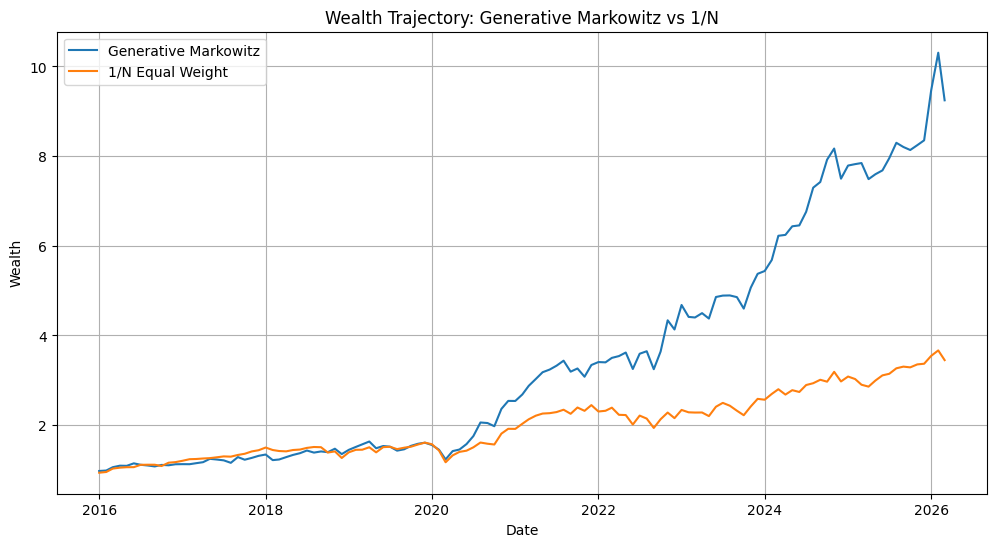

In [ ]:
# ============================================================
# 12. Plot Wealth Trajectory
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    bt_df.index,
    bt_df["Generative_Markowitz_Wealth"],
    label="Generative Markowitz",
)

plt.plot(
    bt_df.index,
    bt_df["Equal_Weight_Wealth"],
    label="1/N Equal Weight",
)

plt.title("Wealth Trajectory: Generative Markowitz vs 1/N")
plt.xlabel("Date")
plt.ylabel("Wealth")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# 13. Average Portfolio Weights
# ============================================================

weights = backtest_results["gm_weights"]

weights_df = pd.DataFrame(
    weights,
    index=backtest_results["dates"],
    columns=industry_names,
)

avg_weights_df = pd.DataFrame(
    {
        "Industry": industry_names,
        "Average_GM_Weight": weights_df.mean(axis=0).values,
        "Equal_Weight": np.ones(num_assets) / num_assets,
    }
).sort_values("Average_GM_Weight", ascending=False)

avg_weights_df.head(20)

,Industry,Average_GM_Weight,Equal_Weight
3,Smoke,0.264542,0.02439
23,Oil,0.183509,0.02439
2,Beer,0.091673,0.02439
25,Telcm,0.081042,0.02439
21,Mines,0.074634,0.02439
24,Util,0.031508,0.02439
35,Meals,0.028199,0.02439
20,Ships,0.027880,0.02439
30,LabEq,0.022535,0.02439
36,Banks,0.018031,0.02439


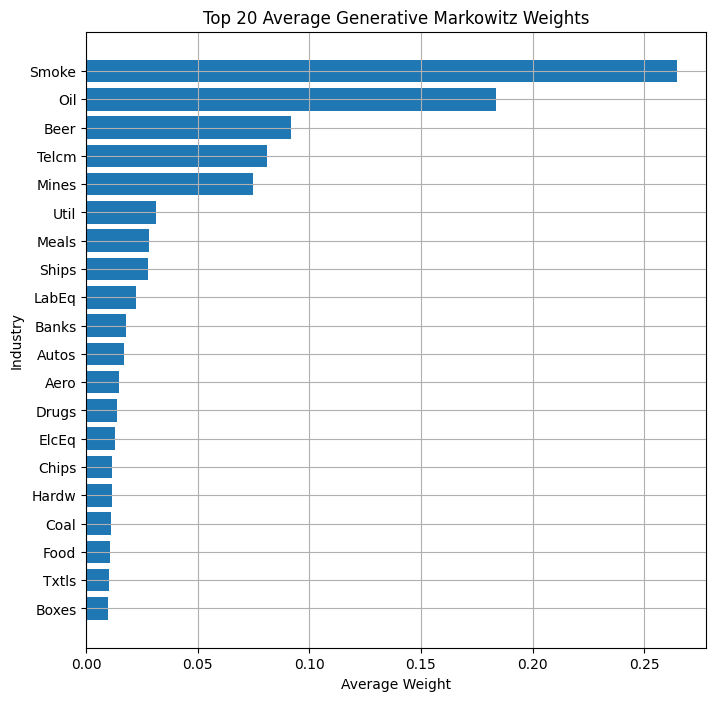

In [ ]:
# ============================================================
# 14. Plot average weights
# ============================================================

top_n = 20

plot_df = avg_weights_df.head(top_n).sort_values("Average_GM_Weight")

plt.figure(figsize=(8, 8))
plt.barh(plot_df["Industry"], plot_df["Average_GM_Weight"])
plt.title(f"Top {top_n} Average Generative Markowitz Weights")
plt.xlabel("Average Weight")
plt.ylabel("Industry")
plt.grid(True)
plt.show()

Average monthly turnover: 1.0064952352057919
Median monthly turnover: 1.0096221961542475
Max monthly turnover: 1.9999991853602515


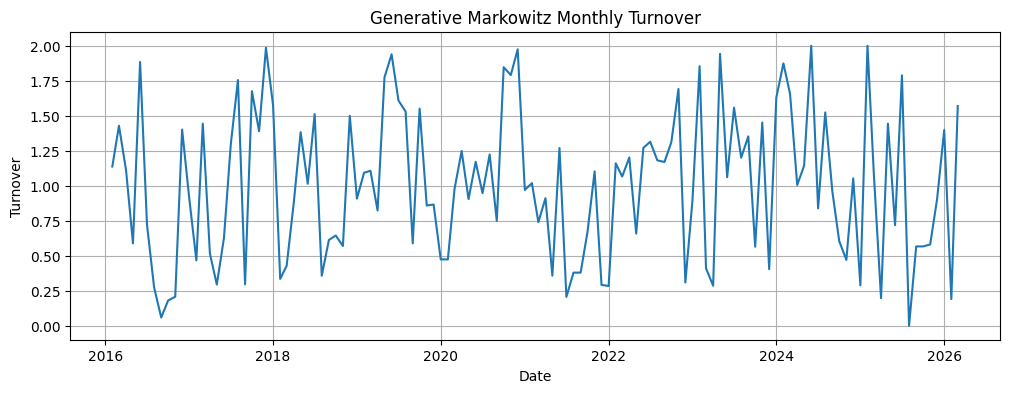

In [ ]:
# ============================================================
# 15. Turnover
# ============================================================

turnover = np.abs(weights[1:] - weights[:-1]).sum(axis=1)

turnover_df = pd.DataFrame(
    {
        "Turnover": turnover,
    },
    index=backtest_results["dates"][1:],
)

print("Average monthly turnover:", turnover.mean())
print("Median monthly turnover:", np.median(turnover))
print("Max monthly turnover:", turnover.max())

plt.figure(figsize=(12, 4))
plt.plot(turnover_df.index, turnover_df["Turnover"])
plt.title("Generative Markowitz Monthly Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# 16. Save Results
# ============================================================

bt_df.to_csv("backtest_generative_markowitz_vs_equal_weight.csv")
weights_df.to_csv("generative_markowitz_monthly_weights.csv")
stats_df.to_csv("performance_stats.csv")
avg_weights_df.to_csv("average_weights.csv")

print("Saved:")
print("backtest_generative_markowitz_vs_equal_weight.csv")
print("generative_markowitz_monthly_weights.csv")
print("performance_stats.csv")
print("average_weights.csv")

Saved:
backtest_generative_markowitz_vs_equal_weight.csv
generative_markowitz_monthly_weights.csv
performance_stats.csv
average_weights.csv


In [ ]:
# ============================================================
# Save Generated Scenario Dataset for RL
# ============================================================

scenario_dates = backtest_results["dates"]
asset_names = list(monthly_returns_df.columns)

scenarios_raw = backtest_results["scenarios_raw"]
scenarios_std = backtest_results["scenarios_standardized"]
actual_next_returns = backtest_results["actual_next_returns"]
history_raw = backtest_results["history_windows_raw"]
history_std = backtest_results["history_windows_standardized"]
gm_weights = backtest_results["gm_weights"]

print("scenarios_raw shape:", scenarios_raw.shape)
print("scenarios_standardized shape:", scenarios_std.shape)
print("actual_next_returns shape:", actual_next_returns.shape)
print("history_windows_raw shape:", history_raw.shape)
print("gm_weights shape:", gm_weights.shape)

# ------------------------------------------------------------
# 1. Save compact tensor format for RL
# ------------------------------------------------------------

np.savez_compressed(
    "ff49_diffusion_scenarios_for_rl.npz",

    # Main generated scenario tensor:
    # [T_test, num_scenarios, num_assets]
    scenarios_raw=scenarios_raw,
    scenarios_standardized=scenarios_std,

    # Date of each scenario set:
    # length T_test
    dates=scenario_dates.astype(str).to_numpy(),

    # Asset names:
    # length num_assets
    asset_names=np.asarray(asset_names),

    # Realized next-month return for reward computation:
    # [T_test, num_assets]
    actual_next_returns=actual_next_returns,

    # Historical state windows:
    # [T_test, context_length, num_assets]
    history_windows_raw=history_raw,
    history_windows_standardized=history_std,

    # Optional: Markowitz weights from your current method:
    # [T_test, num_assets]
    gm_weights=gm_weights,

    # Scenario moments:
    scenario_means=backtest_results["scenario_means"],
    scenario_covs=backtest_results["scenario_covs"],
)

print("Saved: ff49_diffusion_scenarios_for_rl.npz")

In [ ]:
# ------------------------------------------------------------
# 2. Save wide CSV panel format
# One row = one generated scenario for one date
# ------------------------------------------------------------

T, S, N = scenarios_raw.shape

scenario_panel_df = pd.DataFrame(
    scenarios_raw.reshape(T * S, N),
    columns=asset_names,
)

scenario_panel_df.insert(
    0,
    "scenario_id",
    np.tile(np.arange(S), T),
)

scenario_panel_df.insert(
    0,
    "date",
    np.repeat(scenario_dates.astype(str).to_numpy(), S),
)

scenario_panel_df.to_csv(
    "ff49_diffusion_scenarios_for_rl_panel.csv",
    index=False,
)

print("Saved: ff49_diffusion_scenarios_for_rl_panel.csv")
scenario_panel_df.head()

In [ ]:
actual_next_returns_df = pd.DataFrame(
    actual_next_returns,
    index=scenario_dates,
    columns=asset_names,
)

actual_next_returns_df.to_csv(
    "ff49_actual_next_returns_for_rl.csv"
)

print("Saved: ff49_actual_next_returns_for_rl.csv")
actual_next_returns_df.head()